reginoes y fronteras


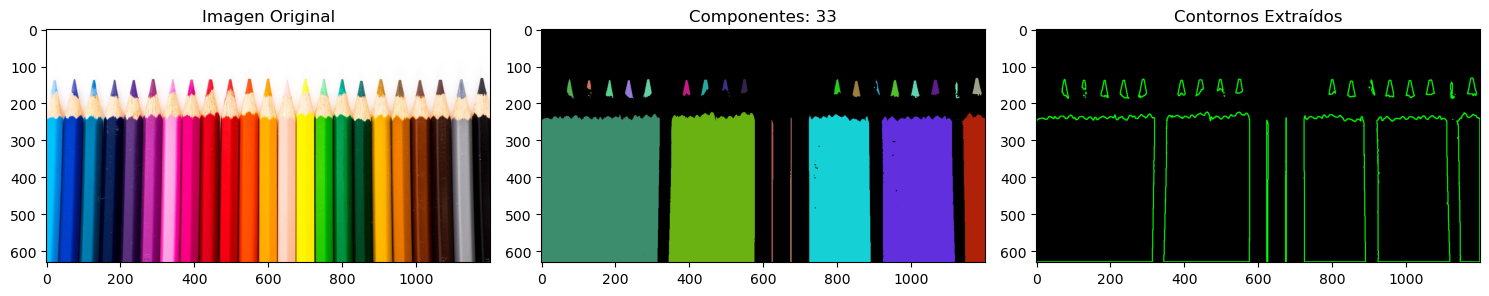

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar imagen
img = cv2.imread(r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg')
if img is None:
    print("Error: No se pudo cargar la imagen. Revisa la ruta.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Preprocesamiento
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    # cv2.threshold devuelve una tupla (ret, thresh), necesitamos el segundo valor [1]
    _, binary = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Componentes conectados
    # num_labels es el conteo, labels es la matriz etiquetada
    num_labels, labels = cv2.connectedComponents(binary)

    # 4. Colorear componentes
    colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]  # Fondo negro
    colorear = colors[labels]

    # 5. Encontrar contornos
    # findContours devuelve una tupla; los contornos están en el índice [0]
    contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contorno_fin = cv2.drawContours(np.zeros_like(img), contornos, -1, (0, 255, 0), 2)

    # 6. Visualización
    plt.figure(figsize=(15, 5))

    plt.subplot(131)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagen Original')

    plt.subplot(132)
    # Colorear ya está en formato RGB/BGR dependiendo de cómo lo definas, 
    # pero matplotlib espera RGB.
    plt.imshow(cv2.cvtColor(colorear, cv2.COLOR_BGR2RGB))
    plt.title(f'Componentes: {num_labels - 1}')

    plt.subplot(133)
    plt.imshow(cv2.cvtColor(contorno_fin, cv2.COLOR_BGR2RGB))
    plt.title('Contornos Extraídos')

    plt.tight_layout()
    plt.show() # Faltaban los paréntesis ()

conectividad

In [ ]:
import cv2
import numpy as np  
import matplotlib.pyplot as plt
from skimage import measure
def Contar_elementos(imagen):
    # Convertir a escala de grises
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Aplicar umbral para binarizar la imagen estos valores son calve para probar diferentes umbrales y ver cuál funciona mejor para tu imagen
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)


    
    # Etiquetar los componentes conectados cuando hay un 2 es de 4  y cuando es 1= es para 8
    e_img = measure.label(binary, connectivity=2)
    
    # Contar el número de componentes (excluyendo el fondo)
    num_objetos = np.max(e_img)
    
    return num_objetos;
    img = cv2.imread(r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg')

    


Éxito: Se han detectado 109 objetos en la imagen.


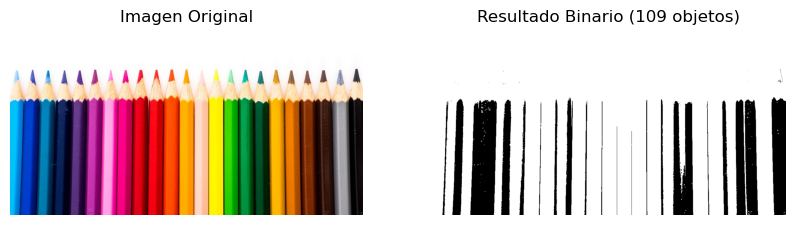

In [10]:
import cv2  # OpenCV: Librería principal para procesamiento de imágenes y visión artificial
import numpy as np  # NumPy: Manejo de matrices (las imágenes se cargan como matrices de píxeles)
import matplotlib.pyplot as plt  # Matplotlib: Para mostrar las imágenes en ventanas gráficas
from skimage import measure  # Scikit-image: Contiene algoritmos avanzados como el etiquetado de objetos

def contar_elementos(imagen):
    """
    Función que procesa una imagen para contar cuántos objetos aislados contiene.
    Retorna el número total de objetos y la imagen binarizada.
    """
    
    # 1. Conversión a escala de grises:
    # Se reduce la información de 3 canales (Color) a 1 solo canal (Intensidad).
    # Esto facilita la detección de formas.
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # 2. Binarización (Umbralización):
    # Todo píxel con valor > 50 se convierte en blanco (255).
    # Todo píxel con valor <= 50 se convierte en negro (0).
    # 'binary' es ahora una imagen en blanco y negro puro.
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    # 3. Etiquetado de componentes conectados:
    # 'measure.label' escanea la imagen y asigna un número único a cada grupo de píxeles blancos.
    # 'connectivity=2' significa que detecta vecinos en horizontal, vertical y diagonal (8-vecindad).
    e_img = measure.label(binary, connectivity=2)
    
    # 4. Conteo final:
    # El valor más alto en la matriz etiquetada nos indica cuántos grupos distintos se encontraron.
    num_objetos = np.max(e_img)
    
    return num_objetos, binary

# ==========================================================
# FLUJO PRINCIPAL DEL PROGRAMA
# ==========================================================

# Definimos la ruta de la imagen (usa 'r' antes de la cadena para evitar problemas con las barras \)
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg'

# Intentamos cargar la imagen desde el disco
img = cv2.imread(ruta)

# Validación de seguridad: verificamos si la imagen realmente existe y se cargó
if img is None:
    print("Error: No se pudo cargar la imagen. Revisa si el nombre y la ruta son correctos.")
else:
    # Llamamos a la función de procesamiento
    total, imagen_binaria = contar_elementos(img)
    print(f"Éxito: Se han detectado {total} objetos en la imagen.")

    # --- Configuración de la Visualización ---
    plt.figure(figsize=(10, 5)) # Definimos el tamaño de la ventana

    # Mostramos la Imagen Original
    plt.subplot(1, 2, 1) # 1 fila, 2 columnas, posición 1
    plt.title("Imagen Original")
    # OpenCV carga en BGR, pero Matplotlib usa RGB; por eso lo convertimos aquí:
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off') # Ocultamos los ejes de coordenadas

    # Mostramos la Imagen Binarizada (Resultado del procesamiento)
    plt.subplot(1, 2, 2) # 1 fila, 2 columnas, posición 2
    plt.title(f"Resultado Binario ({total} objetos)")
    plt.imshow(imagen_binaria, cmap='gray') # Usamos el mapa de colores gris
    plt.axis('off')

    # Desplegamos la ventana con ambas imágenes
    plt.show()

Pruba de K-means 

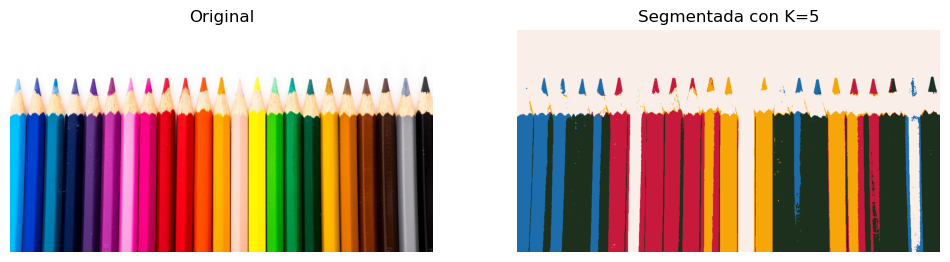

Colores dominantes detectados (RGB):
Color 1: [246 166   8]
Color 2: [ 29 109 172]
Color 3: [28 48 29]
Color 4: [250 238 233]
Color 5: [198  25  59]


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def identificar_colores_kmeans(imagen, k=4):
    # 1. Preparar los datos: Convertimos la imagen de 2D a una lista de píxeles (3D: R,G,B)
    # Reorganizamos la matriz de (alto, ancho, 3) a (píxeles_totales, 3)
    data = imagen.reshape((-1, 3))
    data = np.float32(data) # K-means en OpenCV requiere datos tipo float32

    # 2. Definir criterios de parada (Iteraciones o precisión)
    # Detenerse cuando se cumplan 10 iteraciones o la precisión sea de 1.0
    criterios = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

    # 3. Aplicar K-Means
    # 'ret' es la compactación, 'label' son los grupos, 'center' son los colores promedio
    ret, label, center = cv2.kmeans(data, k, None, criterios, 10, cv2.KMEANS_RANDOM_CENTERS)

    # 4. Convertir los centros a colores enteros (8 bits)
    center = np.uint8(center)
    
    # 5. Reconstruir la imagen con solo los K colores
    res = center[label.flatten()]
    img_segmentada = res.reshape((imagen.shape))

    return img_segmentada, center

# --- Flujo Principal ---
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg'
img = cv2.imread(ruta)

if img is None:
    print("No se encontró la imagen.")
else:
    # Convertimos a RGB para que los colores se vean bien en Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Ejecutamos K-means pidiendo, por ejemplo, 5 colores dominantes
    k_deseado = 5
    img_final, colores_encontrados = identificar_colores_kmeans(img_rgb, k=k_deseado)

    # Mostrar resultados
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Segmentada con K={k_deseado}")
    plt.imshow(img_final)
    plt.axis('off')

    plt.show()

    # Imprimir la paleta de colores detectada (valores RGB)
    print("Colores dominantes detectados (RGB):")
    for i, color in enumerate(colores_encontrados):
        print(f"Color {i+1}: {color}")

segmentando por region

Se encontraron 109 regiones individuales.

Objeto 1: Color promedio RGB [202 169 150] -> Detectado como: Rojizo/Naranja
Objeto 2: Color promedio RGB [165   1   8] -> Detectado como: Rojizo/Naranja
Objeto 3: Color promedio RGB [81 48 41] -> Detectado como: Rojizo/Naranja
Objeto 4: Color promedio RGB [ 42  55 105] -> Detectado como: Azulado
Objeto 5: Color promedio RGB [60 54 58] -> Detectado como: Rojizo/Naranja
Objeto 6: Color promedio RGB [ 36  55 102] -> Detectado como: Azulado
Objeto 7: Color promedio RGB [80 41 93] -> Detectado como: Azulado
Objeto 8: Color promedio RGB [75 44 33] -> Detectado como: Rojizo/Naranja
Objeto 9: Color promedio RGB [77 43 35] -> Detectado como: Rojizo/Naranja
Objeto 10: Color promedio RGB [ 33  54 112] -> Detectado como: Azulado
Objeto 11: Color promedio RGB [ 85  56 118] -> Detectado como: Azulado
Objeto 12: Color promedio RGB [85 59 51] -> Detectado como: Rojizo/Naranja
Objeto 13: Color promedio RGB [ 35  52 106] -> Detectado como: Azulado
Objeto 14: C

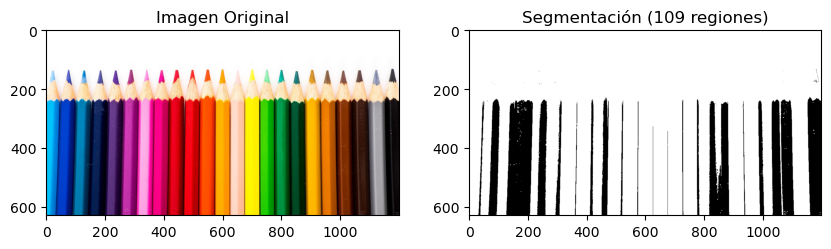

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def analizar_colores_por_region(imagen):
    # 1. Preparación: Convertir a grises y binarizar para encontrar objetos
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    # Ajustamos el umbral (puedes usar cv2.THRESH_OTSU si no sabes el valor)
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    # 2. Etiquetado: Separar cada objeto en una región independiente
    # e_img contiene la misma forma que la imagen, pero con números (0=fondo, 1=objeto1, 2=objeto2...)
    e_img = measure.label(binary, connectivity=2)
    num_objetos = np.max(e_img)
    
    # Convertimos la imagen original a RGB para que los promedios de color tengan sentido
    img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    resultados = []

    # 3. Analizar cada región por separado
    for i in range(1, num_objetos + 1):
        # Creamos una "máscara" que solo activa los píxeles del objeto actual
        mask_objeto = (e_img == i)
        
        # Extraemos los píxeles de la imagen original que pertenecen a este objeto
        pixeles_objeto = img_rgb[mask_objeto]
        
        # Calculamos el color promedio del objeto (R, G, B)
        color_promedio = np.mean(pixeles_objeto, axis=0).astype(int)
        
        # Clasificación simple por lógica de canales (puedes ampliar esto)
        r, g, b = color_promedio
        etiqueta_color = "Indefinido"
        
        if r > g and r > b:
            etiqueta_color = "Rojizo/Naranja"
        elif g > r and g > b:
            etiqueta_color = "Verdoso"
        elif b > r and b > g:
            etiqueta_color = "Azulado"
            
        resultados.append({
            "id": i,
            "color_rgb": color_promedio,
            "clase": etiqueta_color
        })

    return num_objetos, resultados, binary

# --- Flujo Principal ---
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg'
img = cv2.imread(ruta)

if img is None:
    print("No se encontró la imagen.")
else:
    total, info_colores, binaria = analizar_colores_por_region(img)
    
    print(f"Se encontraron {total} regiones individuales.\n")
    
    for res in info_colores:
        print(f"Objeto {res['id']}: Color promedio RGB {res['color_rgb']} -> Detectado como: {res['clase']}")

    # Visualización
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Imagen Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    plt.subplot(1, 2, 2)
    plt.title(f"Segmentación ({total} regiones)")
    plt.imshow(binaria, cmap='gray')
    plt.show()